<a href="https://colab.research.google.com/github/Asrorbek-FinAI/Linear-and-Logistic-regressions-/blob/main/loyiha_github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("/content/dataset_study.csv")

In [ ]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      5000 non-null   int64  
 1    "study hours"  5000 non-null   float64
 2    "scores"       5000 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 117.3 KB
None
   student_id   "study hours"   "scores"
0           1            9.15      91.91
1           2            9.37      86.81
2           3            2.86      53.39
3           4            8.30      85.52
4           5            6.42      77.98


In [ ]:
df.columns = df.columns.str.strip().str.replace('"', '')
print(df.columns.tolist())

['student_id', 'study hours', 'scores']


In [ ]:
X = df['study hours']
y = df['scores']

In [ ]:
y = (df['scores'] >= 60).astype(int)

In [ ]:
w = 0
b = 0
lr = 0.1
epochs = 1000

In [ ]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))
w, b = 0, 0
lr = 0.1
epochs = 1000

X = df['study hours']
y = (df['scores'] >= 60).astype(int)  #bunda talaba 60 baldan yuqori bo'lsa 1, past bo'lsa 0 ya'ni bu orqali biz talabani qancha dars qilsa imtihondan o'tish yoki o'tmasligini bashorat qilishimiz mumkin

for epochs in range(epochs):
  z = w * X + b
  p = sigmoid(z)
  loss = -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

  dz = p-y
  dw = np.mean((p-y)*X)
  db = np.mean(p-y)
  w = w - lr * dw
  b = b - lr * db
print(f"w={w:.3f}, b={b:.3f}")
print(f"loss={loss}")

w=0.811, b=-3.201
loss=0.34690428981685256


In [ ]:
p = sigmoid(X*w + b)
pred = (p >= 0.6).astype(int)
print("probability :", np.round(p, 3))
print("predicted :", pred)
print("true label :", y.astype(int))
print("accuracy :", np.mean(pred==y))

probability : 0       0.986
1       0.988
2       0.293
3       0.972
4       0.882
        ...  
4995    0.683
4996    0.597
4997    0.992
4998    0.917
4999    0.059
Name: study hours, Length: 5000, dtype: float64
predicted : 0       1
1       1
2       0
3       1
4       1
       ..
4995    1
4996    0
4997    1
4998    1
4999    0
Name: study hours, Length: 5000, dtype: int64
true label : 0       1
1       1
2       0
3       1
4       1
       ..
4995    0
4996    1
4997    1
4998    1
4999    0
Name: scores, Length: 5000, dtype: int64
accuracy : 0.8396


AUC = 0.923


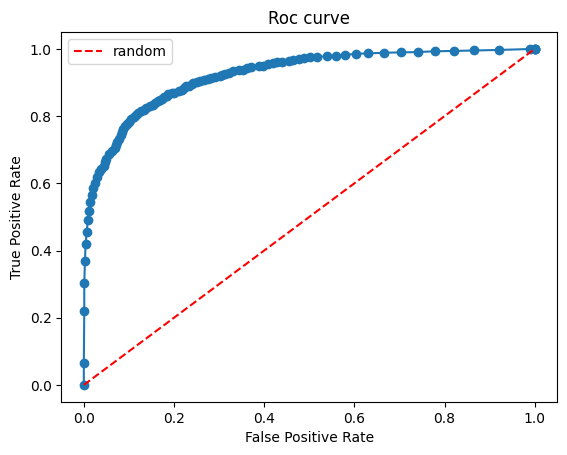

In [ ]:
import matplotlib.pyplot as plt

thresholds = np.linspace(1, 0, 100)
tpr = []
fpr = []
P = np.sum(y==1)
N = np.sum(y==0)
for t in thresholds:
  pr = (p >= t).astype(int)
  tpr.append(np.sum((pr == 1) & (y == 1)) / P)
  fpr.append(np.sum((pr == 1) & (y == 0)) / N)
tpr = np.array(tpr)
fpr = np.array(fpr)
auc = np.trapezoid(tpr, fpr)
print("AUC =", round(auc, 3))

plt.plot(fpr, tpr, 'o-')
plt.plot([0, 1], [0, 1], '--', color='red', label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc curve')
plt.legend()
plt.show()

*LINEAR REGRESSION*  

In [ ]:
import sympy as sp

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['study hours']]
y = df['scores']

model = LinearRegression()
model.fit(X, y)

print("w =", model.coef_[0])
print("b =", model.intercept_)
print("R2 =", model.score(X, y))

w = 5.0128182826293175
b = 39.746944836935064
R2 = 0.6827674621005203


In [ ]:
yangi = pd.DataFrame({
    'study hours': [12]
})
p = model.predict(yangi)  # bunday predict qilib ko'rik yani talaba 12 sat dars qilsa qancha ball oladi
print(p.round(0))

[100.]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
model.score(X_test, y_test)

0.6788564645776802

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE =", round(mae, 2))
print("RMSE =", round(rmse, 2))
print("MSE =", round(mse, 2))

MAE = 8.1
RMSE = 10.13
MSE = 102.66


In [ ]:
x = df['study hours']
y = df['scores']

w=0
b=0
lr=0.01
def cost(w, b):
  pred = w*x+b
  return np.mean ((pred-y)**2)

for qadam in range(200):
  pred = w*x+b
  dw = np.mean(2*(pred-y)*x)
  db = np.mean(2*(pred-y))
  w = w-lr*dw
  b = b-lr*db
  if qadam % 20 ==0:
    print(f"w={w:.3f}, b={b:.3f}, cost={cost(w, b):.3f}")


w=7.387, b=1.299, cost=848.901
w=10.173, b=5.351, cost=395.510
w=9.689, b=8.572, cost=342.558
w=9.251, b=11.491, cost=299.059
w=8.855, b=14.137, cost=263.325
w=8.495, b=16.535, cost=233.970
w=8.169, b=18.709, cost=209.855
w=7.873, b=20.679, cost=190.046
w=7.605, b=22.465, cost=173.772
w=7.363, b=24.083, cost=160.404
